# Classical Shadows Simulations — Results

This notebook loads and plots the results of every simulation run in the
`Simulación Shadows` project. It does **not** repeat any computation: all
figures below are built from the `.npz` files already saved by
`Simulacion_Shadow.ipynb`, `Sim_Shadow_Max_Ent.ipynb`, and
`Sim_Shadow_Schmidt_y_Werner.ipynb`, stored in `Simulacion_01/`,
`Simulacion_02/`, and `Simulacion_03/`.

**Common setup.** Every simulation optimizes the same "wagon-wheel"
Bell-type functional $I_{\rm w-w}$ over a triangular network of three
sources feeding six qubits (two qubits per detector), using CSPSA
(`gains=[3, 0, 0.1, 0.602, 0.101]`, `minimize=False`, i.e. maximization).
Each of the three sources distributes an identical two-qubit state, drawn
from one of three families:

- **Maximally entangled state** — the singlet $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, no free parameter.
- **Schmidt state** — $\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, $a\in[0,0.5]$ ($a=0$: product state, $a=0.5$: maximally entangled state).
- **Werner state** — $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$, $p\in[0,1]$ ($p=0$: maximally mixed state, $p=1$: pure singlet).

Simulations are grouped below in that order: **maximally entangled state**
first, then **Schmidt states**, then **Werner states**.

**Evaluation levels** used across simulations (not all appear in every run):

- **Exact** — $I_{\rm w-w}$ evaluated exactly on the true state $\rho$.
- **Tomo** — a classical shadow is trained, a density matrix $\hat\rho$ is reconstructed from it, and $I_{\rm w-w}$ is evaluated exactly on $\hat\rho$.
- **Shadow** — $I_{\rm w-w}$ is estimated directly from the classical shadow (global-observable estimation, no control variate).
- **EnhShadow** — same as Shadow, but with a control-variate correction that uses $\hat\rho$ as reference.
- **Mix** (a.k.a. Shadow-Exact) — the optimization trajectory is guided by the Shadow-estimated gradient, but $I_{\rm w-w}$ is evaluated exactly at each visited point (diagnostic only; it does not affect the optimization).

The classical bound of the inequality is $I_{\rm w-w}=0$; the quantum
maximum is $I_{\rm w-w}^{\max}=(\sqrt{2}-1)/16$.

Figures are displayed inline and also saved as PDF into a new `Figuras_EN/`
folder, so the original (Spanish-labeled) figures in `Simulacion_01/02/03`
are left untouched.

## Summary of all simulations

| Group | Sim ID | Source notebook | Parameter sweep | $N_{\rm sh}$ | N_rep | N_it | Evaluation levels | Data files |
|---|---|---|---|---|---|---|---|---|
| Max. entangled | **Sim01** | `Simulacion_Shadow.ipynb` / `Sim_Shadow_Max_Ent.ipynb` | — (base case) | $10\,000$ (doc.) / $10^5$ (code)$^\dagger$ | 100 | 1000 | Tomo, Shadow, EnhShadow | `Sim01.npz` |
| Max. entangled | **Sim01_02** | `Sim_Shadow_Max_Ent.ipynb` | — (fixed state) | $\{10^3,10^4,10^5,10^6\}$ | 100 | 1000 | Shadow only | `Sim01_02_N1e{3,4,5,6}.npz` |
| Max. entangled | **Sim01_03** | `Sim_Shadow_Max_Ent.ipynb` | — (fixed state) | $\{10^3,10^4,10^5,10^6\}$ | 100 | 1000 | Exact, Shadow (two *independent* trajectories) | `Sim01_03_N1e{3,4,5,6}.npz` (superseded by Sim01_04) |
| Max. entangled | **Sim01_04** | `Sim_Shadow_Max_Ent.ipynb` | — (fixed state) | $\{10^3,10^4,10^5,10^6\}$ | 100 + 100 | 1000 | Exact, Mix, Shadow (Mix/Shadow share one trajectory) | `Sim01_04_N1e{3,4,5,6}.npz` |
| Schmidt | **Sim02_01** | `Simulacion_Shadow.ipynb` | $a\in\{0.0,0.1,0.2,0.3,0.4,0.5\}$ | $10\,000$ | 100 | 1000 | Tomo, Shadow, EnhShadow | `Sim02_01_a{val}.npz` |
| Schmidt | **Sim02_02** | `Simulacion_Shadow.ipynb` | $a\in\{0.30,0.35,0.40,0.45,0.50\}$ (refined) | $10\,000$ | 100 | 1000 | Tomo, Shadow, EnhShadow | `Sim02_02_a{val}.npz` |
| Schmidt | **Sim02_03_01** | `Sim_Shadow_Schmidt_y_Werner.ipynb` | $a\in\{0.00,0.25,0.50\}$ | $\{10^5,10^6\}$ | 100 + 100 | 1000 | Exact, Mix, Shadow | `Sim02_03_01_a{val}_N1e{5,6}.npz` |
| Schmidt | **Sim02_03_02** | `Sim_Shadow_Schmidt_y_Werner.ipynb` | $a\in\{0.30,0.35,0.40,0.45,0.50\}$ (refined) | $\{10^5,10^6\}$ | 100 + 100 | 1000 | Exact, Mix, Shadow | `Sim02_03_02_a{val}_N1e{5,6}.npz` |
| Werner | **Sim03_01** | `Simulacion_Shadow.ipynb` | $p\in\{0.0,0.1,\dots,1.0\}$ | $10\,000$ | 100 | 1000 | Tomo, Shadow, EnhShadow | `Sim03_01_p{val}.npz` |
| Werner | **Sim03_02** | `Simulacion_Shadow.ipynb` | $p\in\{0.90,0.91,\dots,1.00\}$ (refined) | $10\,000$ | 100 | 1000 | Tomo, Shadow, EnhShadow | `Sim03_02_p{val}.npz` |
| Werner | **Sim03_03_01** | `Sim_Shadow_Schmidt_y_Werner.ipynb` | $p\in\{0.0,0.2,0.4,0.6,0.8,1.0\}$ | $\{10^5,10^6\}$ | 100 + 100 | 1000 | Exact, Mix, Shadow | `Sim03_03_01_p{val}_N1e{5,6}.npz` |
| Werner | **Sim03_03_02** | `Sim_Shadow_Schmidt_y_Werner.ipynb` | $p\in\{0.90,0.92,0.94,0.96,0.98,1.00\}$ (refined) | $\{10^5,10^6\}$ | 100 + 100 | 1000 | Exact, Mix, Shadow | `Sim03_03_02_p{val}_N1e{5,6}.npz` |

All runs share `N_it=1000`, `gains=[3, 0, 0.1, 0.602, 0.101]`, and CSPSA
with `minimize=False`.

$^\dagger$ The Sim01 markdown documentation states $N_{\rm sh}=10\,000$,
but the (commented-out) execution cell that generated `Sim01.npz` passes
`N_shadow=100000`. This discrepancy exists in the source notebooks and is
reproduced here for transparency; it could not be resolved without
re-running the simulation.

**Naming convention.** $N_{\rm sh}$ values are written in short
exponential notation, `N1e3`, `N1e4`, ..., where `1e3` denotes
$1\times10^{3}=1000$ (not $10\times10^{3}=10\,000$).

In [1]:
import os
import glob
import re

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

QUANTUM_MAX = (np.sqrt(2) - 1) / 16   # quantum maximum of the wagon-wheel functional
CLASSICAL_BOUND = 0                    # classical bound of the wagon-wheel inequality

FOLDER_MAXENT = "Simulacion_01"
FOLDER_SCHMIDT = "Simulacion_02"
FOLDER_WERNER = "Simulacion_03"

FIG_DIR = "Figuras_EN"
os.makedirs(FIG_DIR, exist_ok=True)


def load_npz(folder, filename):
    """Load the .npz file for a given simulation, located at folder/filename."""
    return np.load(os.path.join(folder, filename))

In [2]:
def plot_convergence_grid(prefix, folder, param_name, param_symbol, title, output_file):
    """
    Search disk for {prefix}_{param_name}*.npz files and build a panel of
    subplots, one per parameter value, each showing the median convergence
    for the three evaluation levels (Tomo, Shadow, EnhShadow), along with
    the classical bound and the quantum maximum.
    """
    pattern = os.path.join(folder, f"{prefix}_{param_name}*.npz")
    files = sorted(glob.glob(pattern))

    data = []
    for path in files:
        name = os.path.basename(path)
        match = re.search(rf"{param_name}([0-9.]+)\.npz", name)
        value = float(match.group(1))
        Data = np.load(path)
        data.append((value, Data))
    data.sort(key=lambda x: x[0])

    n = len(data)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                              sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, (value, Data) in zip(axes, data):
        it = np.arange(len(Data['median1']))
        ax.plot(it, Data['median1'], label="Tomo")
        ax.plot(it, Data['median2'], label="Shadow")
        ax.plot(it, Data['median3'], label="EnhShadow")
        ax.axhline(CLASSICAL_BOUND, linestyle=':', color='gray')
        ax.axhline(QUANTUM_MAX, linestyle='--', color='black')
        ax.set_title(rf"${param_symbol}={value:.2f}$")

    for ax in axes[n:]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5)
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    fig.savefig(os.path.join(FIG_DIR, output_file))
    plt.show()

    return n

In [3]:
def plot_triple_row(prefix, folder, param_name, param_symbol, param_values, exponent,
                     title, output_file, figsize=None):
    """
    Build a single row of subplots, one per value in param_values, each
    loading {prefix}_{param_name}{value}_N1e{exponent}.npz and showing the
    median convergence for Exact, Mix and Shadow, along with the classical
    bound and the quantum maximum. One figure is built per N_sh (this
    matches the exact/mix/shadow plots added to Sim_Shadow_Schmidt_y_Werner.ipynb
    for Sim02_03_01/02, one figure per N_sh value rather than a single
    combined panel).
    """
    n = len(param_values)
    if figsize is None:
        figsize = (4.0 * n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, value in zip(axes, param_values):
        path = os.path.join(folder, f"{prefix}_{param_name}{value:.2f}_N1e{exponent}.npz")
        Data = np.load(path)
        it = np.arange(len(Data['median_ex']))

        ax.plot(it, Data['median_ex'], linewidth=2, label="Exact")
        ax.plot(it, Data['median_mix'], linewidth=2, label="Mix")
        ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
        ax.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2)
        ax.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2)
        ax.set_title(rf"${param_symbol}={value:.2f}$")
        ax.set_xlabel(r"$K$")
        ax.set_ylabel(r"$I_{\rm w-w}$")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3)
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.08, 1, 0.93])
    fig.savefig(os.path.join(FIG_DIR, output_file))
    plt.show()

# 1. Maximally Entangled State

The three sources of the triangular network all distribute the singlet
state $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, which has no free
parameter. This is the base case of the whole series (Sim01), later
explored in more depth in `Sim_Shadow_Max_Ent.ipynb` through Sim01_02,
Sim01_03 and Sim01_04.

## Simulation 01 — Base case

**Data folder:** `Simulacion_01`

| Parameter | Value |
|---|---|
| State (three sources) | Maximally entangled singlet $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, no free parameter |
| $N_{\rm sh}$ (measurements per shadow) | $10\,000$ (doc.) / $10^5$ (code)$^\dagger$, shadow retrained every repetition |
| `N_rep` | 100 |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |

**Description:** first scenario of the series, used as the reference
base case, in which all three sources of the triangular network
distribute the same maximally entangled state, with no free parameter.
Three evaluation levels of the wagon-wheel functional are compared
across iterations: the tomographic reconstruction obtained from the
shadow (`Out1`, Tomo), the direct estimate with standard Classical
Shadows (`Out2`, Shadow), and the control-variate variant (`Out3`,
EnhShadow), all three computed on the same shadow trained at each
repetition.

**Generated files:** `Simulacion_01/Sim01.npz`, with the raw array for
each level (`Out1`, `Out2`, `Out3`, each of size `N_rep` x `N_it`)
together with `mean`, `median`, `q1` and `q3` per iteration for each one
(`mean1`/`median1`/`q1_1`/`q3_1`, and likewise for 2 and 3).

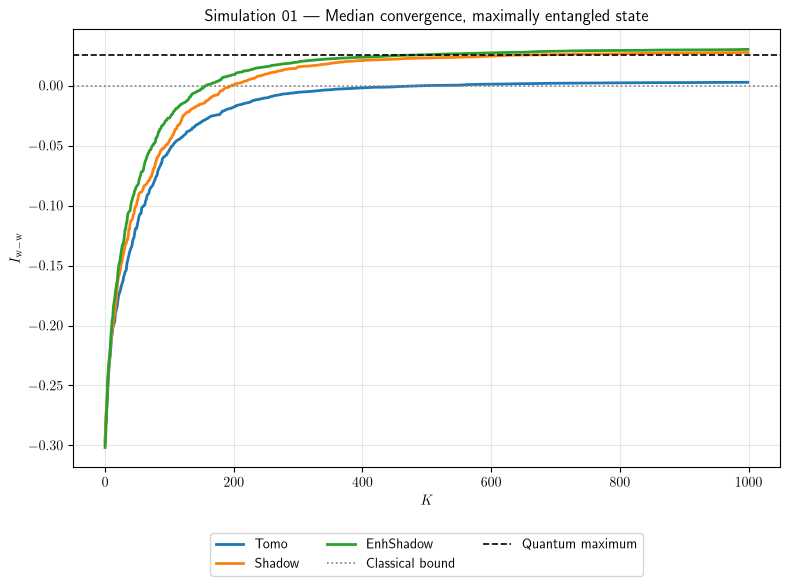

In [4]:
Data = load_npz(FOLDER_MAXENT, "Sim01.npz")
it = np.arange(len(Data['median1']))

plt.figure(figsize=(8, 6))
plt.plot(it, Data['median1'], label="Tomo", linewidth=2)
plt.plot(it, Data['median2'], label="Shadow", linewidth=2)
plt.plot(it, Data['median3'], label="EnhShadow", linewidth=2)
plt.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
plt.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Simulation 01 --- Median convergence, maximally entangled state")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_median_convergence.pdf"))
plt.show()

## Simulation 01_02 — Sweep over number of shadows

**Data folder:** `Simulacion_01`

| Parameter | Value |
|---|---|
| State (three sources) | Maximally entangled singlet, fixed, no free parameter |
| $N_{\rm sh}$ (measurements per shadow) | $\{10^3,\ 10^4,\ 10^5,\ 10^6\}$, shadow retrained every repetition |
| `N_rep` | 100 |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |
| Evaluation level | Shadow only (`obj_fun`), no Tomo or EnhShadow |

**Description:** experiment within Simulation 01, distinct from the base
case already stored in `Sim01.npz`, where the maximally entangled state
is fixed on all three sources and only the number of shadow measurements
$N_{\rm sh}$ used to train it is varied at each repetition. Unlike the
rest of the simulations, only the wagon-wheel functional estimated via
standard Classical Shadows is evaluated here, without the tomographic
reconstruction (Tomo) nor the control-variate correction (EnhShadow),
since the goal is to isolate the effect of $N_{\rm sh}$ on this single
estimator across the $N_{\rm it}$ CSPSA iterations.

**Generated files:** `Simulacion_01/Sim01_02_N1e{3,4,5,6}.npz`, each with
`Out2` (raw array, size `N_rep` x `N_it`, Shadow level) together with
`mean2`, `median2`, `q1_2` and `q3_2` per iteration.

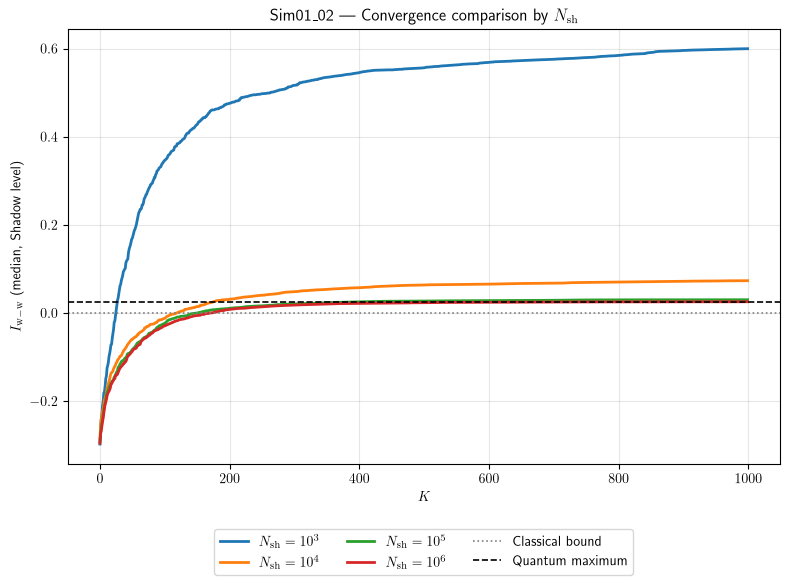

In [5]:
pattern = os.path.join(FOLDER_MAXENT, "Sim01_02_N1e*.npz")
files = sorted(glob.glob(pattern),
               key=lambda f: int(re.search(r"N1e(\d+)", f).group(1)))

plt.figure(figsize=(8, 6))
for path in files:
    exponent = int(re.search(r"N1e(\d+)", path).group(1))
    Data = np.load(path)
    it = np.arange(len(Data['median2']))
    plt.plot(it, Data['median2'], linewidth=2,
             label=rf"$N_{{\rm sh}}=10^{exponent}$")

plt.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
plt.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$ (median, Shadow level)")
plt.title(r"Sim01\_02 --- Convergence comparison by $N_{\rm sh}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_02_comparison.pdf"))
plt.show()

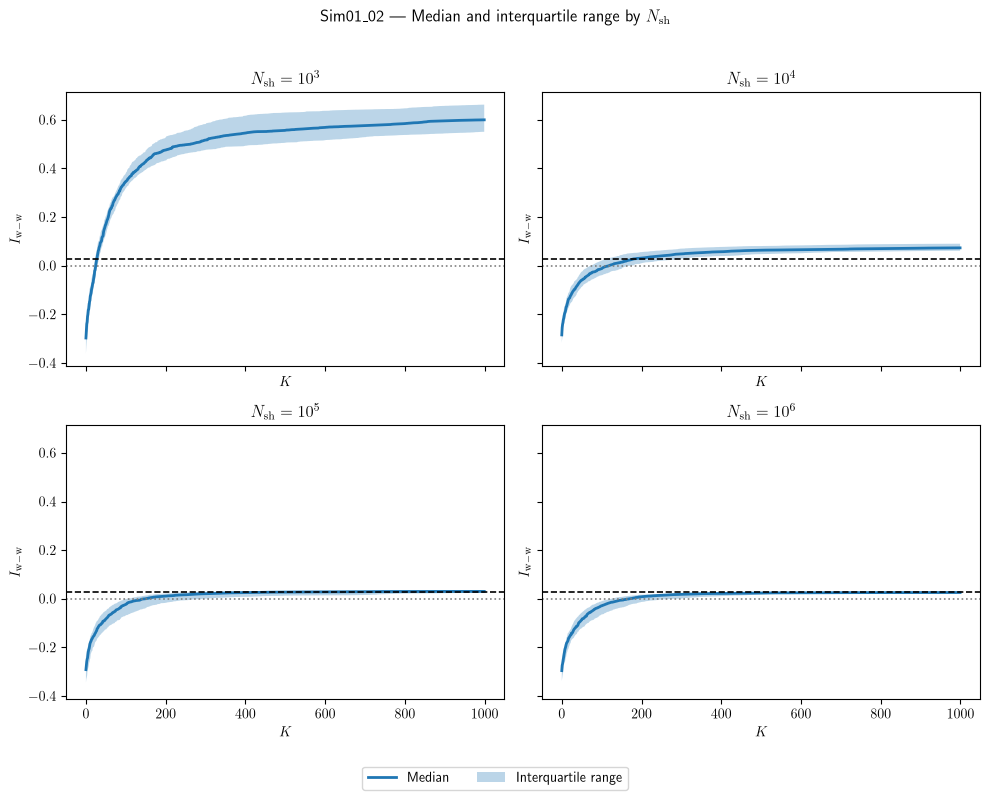

In [6]:
pattern = os.path.join(FOLDER_MAXENT, "Sim01_02_N1e*.npz")
files = sorted(glob.glob(pattern),
               key=lambda f: int(re.search(r"N1e(\d+)", f).group(1)))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, path in zip(axes, files):
    exponent = int(re.search(r"N1e(\d+)", path).group(1))
    Data = np.load(path)
    it = np.arange(len(Data['median2']))
    ax.plot(it, Data['median2'], linewidth=2, label="Median")
    ax.fill_between(it, Data['q1_2'], Data['q3_2'], alpha=0.3, label="Interquartile range")
    ax.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
fig.suptitle(r"Sim01\_02 --- Median and interquartile range by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_02_median_iqr.pdf"))
plt.show()

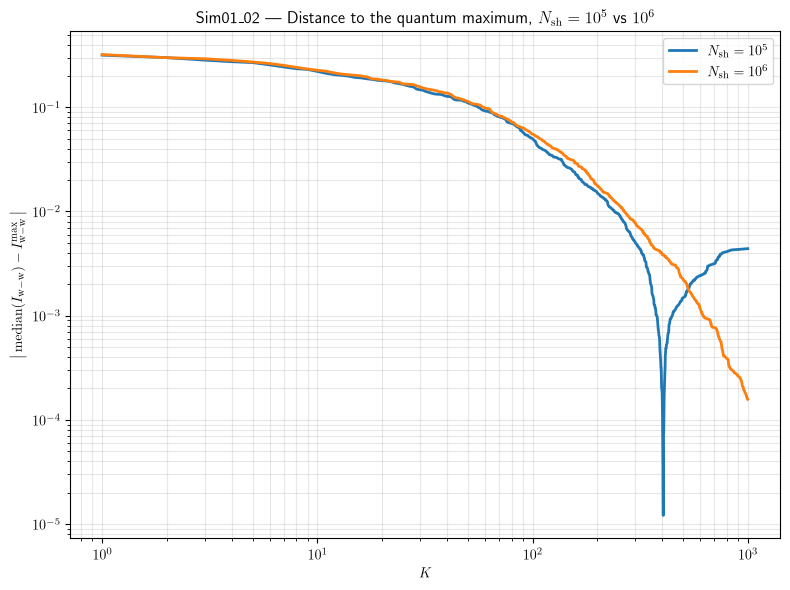

In [7]:
floor = 1e-12
plt.figure(figsize=(8, 6))

for exponent in [5, 6]:
    path = f"{FOLDER_MAXENT}/Sim01_02_N1e{exponent}.npz"
    Data = np.load(path)
    median2, q1_2, q3_2 = Data['median2'], Data['q1_2'], Data['q3_2']

    dist_median = np.clip(np.abs(median2 - QUANTUM_MAX), floor, None)
    dist_q1 = np.clip(np.abs(q1_2 - QUANTUM_MAX), floor, None)
    dist_q3 = np.clip(np.abs(q3_2 - QUANTUM_MAX), floor, None)

    # the absolute value can swap which of q1/q3 ends up closer to or
    # farther from the quantum maximum, so the band uses the pointwise
    # min/max rather than q1/q3 directly
    band_low = np.minimum(dist_q1, dist_q3)
    band_high = np.maximum(dist_q1, dist_q3)

    it = np.arange(1, len(dist_median) + 1)  # starts at 1, log(0) is undefined

    line, = plt.plot(it, dist_median, linewidth=2,
                      label=rf"$N_{{\rm sh}}=10^{exponent}$")
    #plt.fill_between(it, band_low, band_high, alpha=0.25, color=line.get_color())

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{median}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_02 --- Distance to the quantum maximum, $N_{\rm sh}=10^5$ vs $10^6$")
plt.legend(loc='upper right')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_02_distance_to_quantum_max.pdf"))
plt.show()

## Simulation 01_03 — Exact and Shadow evaluation, sweep over $N_{\rm sh}$

**Data folder:** `Simulacion_01`

| Parameter | Value |
|---|---|
| State (three sources) | Maximally entangled singlet, fixed, no free parameter |
| $N_{\rm sh}$ (measurements per shadow) | $\{10^3,\ 10^4,\ 10^5,\ 10^6\}$, shadow retrained every repetition |
| `N_rep` | 100 |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |
| Evaluation levels | Exact (`out_fun` on the true state $\rho$) and Shadow (`obj_fun`) |

**Description:** continuation of Sim01_02, over the same sweep
$N_{\rm sh}\in\{10^3,10^4,10^5,10^6\}$ and the same fixed maximally
entangled state. For each value of $N_{\rm sh}$, two independent
optimizations are run: one guided and evaluated by `out_fun` on the true
state $\rho$ (Exact evaluation), and another guided and evaluated by
`obj_fun` (Shadow), each with its own random seed. The exact evaluation
does not really depend on $N_{\rm sh}$, since it does not use the
shadow, so its four repetitions per file are statistically equivalent to
each other, not a function of $N_{\rm sh}$; they are stored anyway
inside each file to always have the exact reference on hand next to its
corresponding Shadow run. **This simulation is superseded by Sim01_04**,
which fixes the design so Exact and Shadow are compared on the same
trajectory.

**Naming convention:** as in Sim01_02, $N_{\rm sh}$ values are written
in short exponential notation, `N1e3`, `N1e4`, `N1e5`, `N1e6`.

**Generated files:** `Simulacion_01/Sim01_03_N1e{3,4,5,6}.npz`, each with
`Out_ex` (Exact evaluation) and `Out_sh` (Shadow), each of size `N_rep`
x `N_it`, together with `mean`, `median`, `q1` and `q3` per iteration
for both (`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, and likewise with
suffix `_sh`), named this way so as not to be confused with
`Out1`/`Out2` from `Sim01.npz`, where `Out1` corresponds to Tomo (exact
evaluation on $\hat\rho$), not the exact evaluation on $\rho$ stored
here.

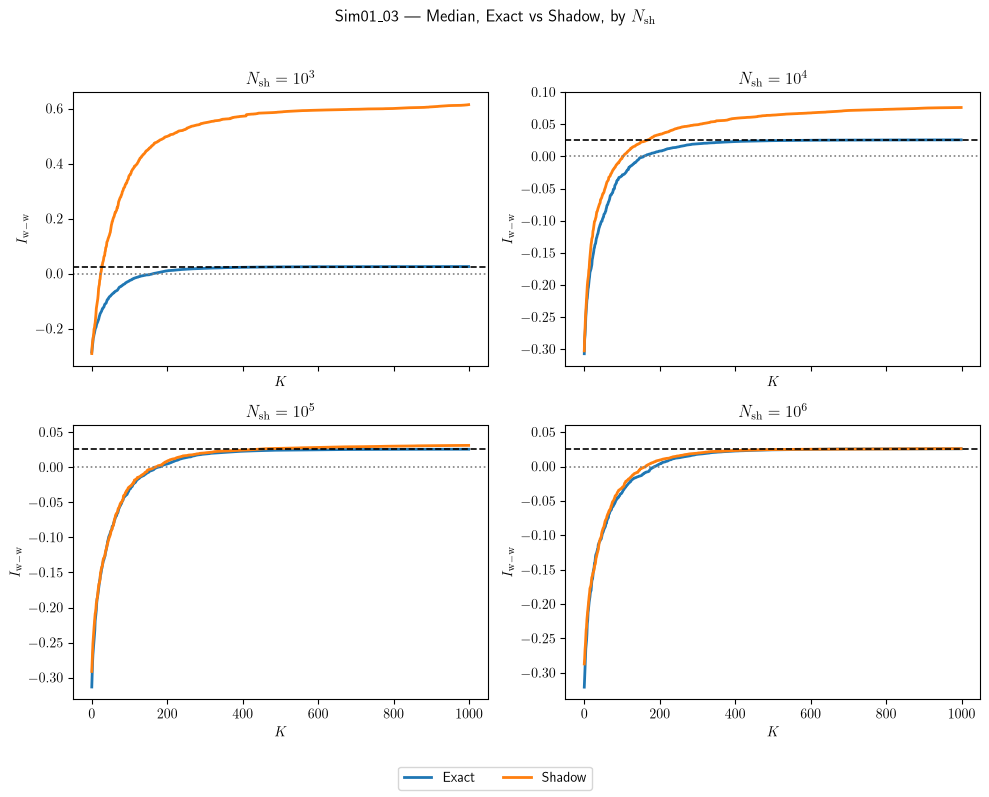

In [8]:
quantum_max = QUANTUM_MAX
top_limits = {3: None, 4: 0.1, 5: 0.06, 6: 0.06}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
axes = axes.reshape(-1)

for ax, exponent in zip(axes, [3, 4, 5, 6]):
    path = f"{FOLDER_MAXENT}/Sim01_03_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exact")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(quantum_max, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

    if top_limits[exponent] is not None:
        ax.set_ylim(top=top_limits[exponent])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4)
fig.suptitle(r"Sim01\_03 --- Median, Exact vs Shadow, by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_03_exact_vs_shadow.pdf"))
plt.show()

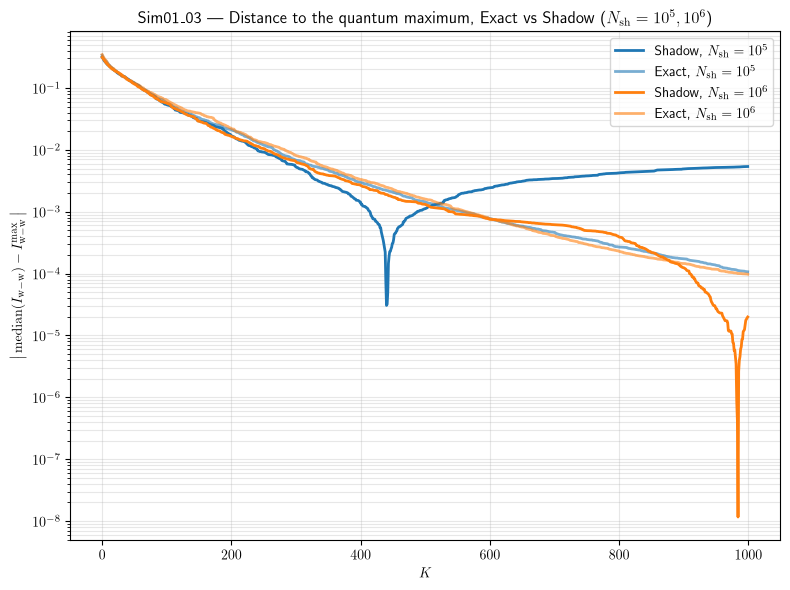

In [9]:
floor = 1e-12
plt.figure(figsize=(8, 6))

for exponent in [5, 6]:
    path = f"{FOLDER_MAXENT}/Sim01_03_N1e{exponent}.npz"
    Data = np.load(path)
    median_sh, median_ex = Data['median_sh'], Data['median_ex']

    dist_sh = np.clip(np.abs(median_sh - QUANTUM_MAX), floor, None)
    dist_ex = np.clip(np.abs(median_ex - QUANTUM_MAX), floor, None)

    it = np.arange(len(dist_sh))  # regular axis, starts at 0

    line, = plt.plot(it, dist_sh, linewidth=2,
                      label=rf"Shadow, $N_{{\rm sh}}=10^{exponent}$")
    plt.plot(it, dist_ex, linewidth=2, alpha=0.6, color=line.get_color(),
              label=rf"Exact, $N_{{\rm sh}}=10^{exponent}$")

plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{median}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_03 --- Distance to the quantum maximum, Exact vs Shadow ($N_{\rm sh}=10^5,10^6$)")
plt.legend(loc='upper right')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_03_distance_to_quantum_max.pdf"))
plt.show()

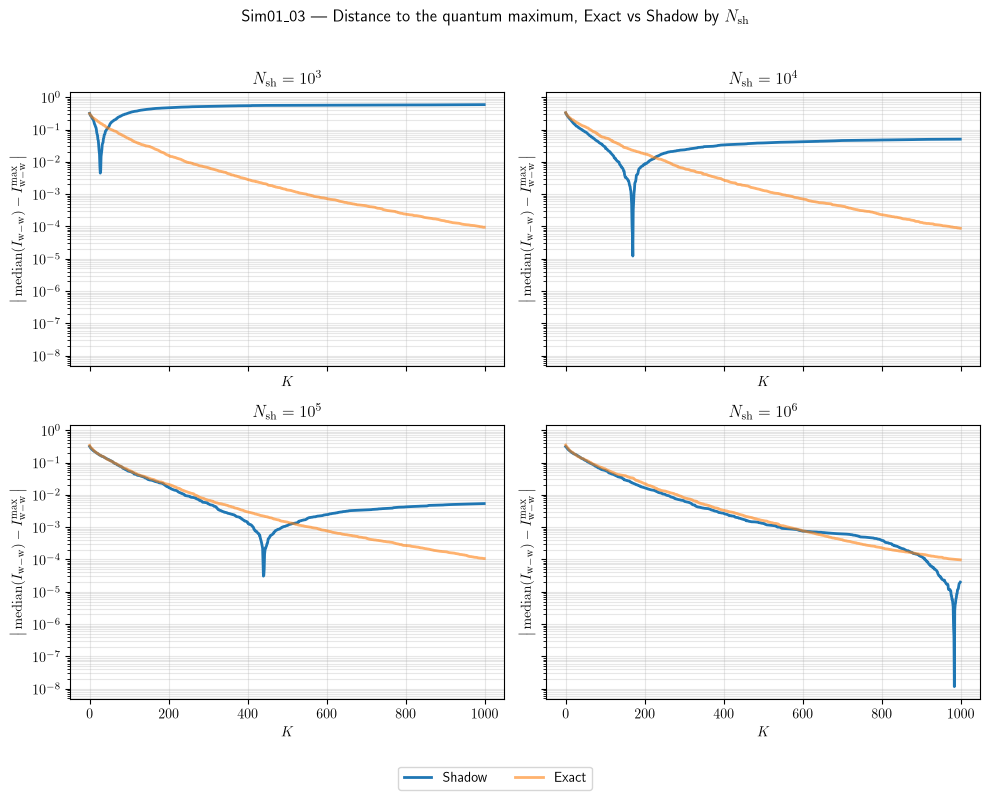

In [10]:
floor = 1e-12
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponent in zip(axes, [3, 4, 5, 6]):
    path = f"{FOLDER_MAXENT}/Sim01_03_N1e{exponent}.npz"
    Data = np.load(path)
    median_sh, median_ex = Data['median_sh'], Data['median_ex']

    dist_sh = np.clip(np.abs(median_sh - QUANTUM_MAX), floor, None)
    dist_ex = np.clip(np.abs(median_ex - QUANTUM_MAX), floor, None)
    it = np.arange(len(dist_sh))

    ax.plot(it, dist_sh, linewidth=2, label="Shadow")
    ax.plot(it, dist_ex, linewidth=2, alpha=0.6, label="Exact")
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\left|\,\mathrm{median}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
fig.suptitle(r"Sim01\_03 --- Distance to the quantum maximum, Exact vs Shadow by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_03_distance_to_quantum_max_grid.pdf"))
plt.show()

## Simulation 01_04 — Exact, Shadow-Exact and Full Shadow, sweep over $N_{\rm sh}$

**Data folder:** `Simulacion_01`

| Parameter | Value |
|---|---|
| State (three sources) | Maximally entangled singlet, fixed, no free parameter |
| $N_{\rm sh}$ (measurements per shadow) | $\{10^3,\ 10^4,\ 10^5,\ 10^6\}$, new shadow every repetition |
| `N_rep` | 100 for the Exact block and 100 for the Shadow-guided block |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |
| Evaluations | Exact; Shadow-Exact; Full Shadow |

**Description:** this simulation replaces Sim01_03 and considers two
optimization blocks.

In the Exact block, CSPSA uses the exact functional both to estimate the
gradient and to record the value reached.

In the second block, CSPSA estimates the gradient via Classical Shadows.
On the same trajectory, two values are recorded after each iteration:

- **Shadow-Exact:** the gradient is estimated via Classical Shadows, but the functional reached is evaluated exactly.
- **Full Shadow:** both the gradient estimation and the functional evaluation are done via Classical Shadows.

Therefore, Shadow-Exact and Full Shadow correspond to the same
optimization points and can be compared directly. The exact evaluation
in Shadow-Exact has a purely diagnostic purpose and does not intervene
in the CSPSA updates.

For each value of $N_{\rm sh}$, $2\times N_{\rm rep}$ optimizations are
run: $N_{\rm rep}$ exact and $N_{\rm rep}$ Shadow-guided.

**Naming convention:** $N_{\rm sh}$ values are written in short
exponential notation: `N1e3`, `N1e4`, `N1e5`, `N1e6`.

**Generated files:** `Simulacion_01/Sim01_04_N1e{3,4,5,6}.npz`.

Each file contains:

- `Out_ex`: Exact optimization.
- `Out_mix`: Shadow-Exact evaluation.
- `Out_sh`: Full Shadow evaluation.

The arrays have dimensions `N_rep` $\times$ `N_it`. The mean, median,
and first/third quartiles per iteration are also stored, using suffixes
`_ex`, `_mix` and `_sh`.

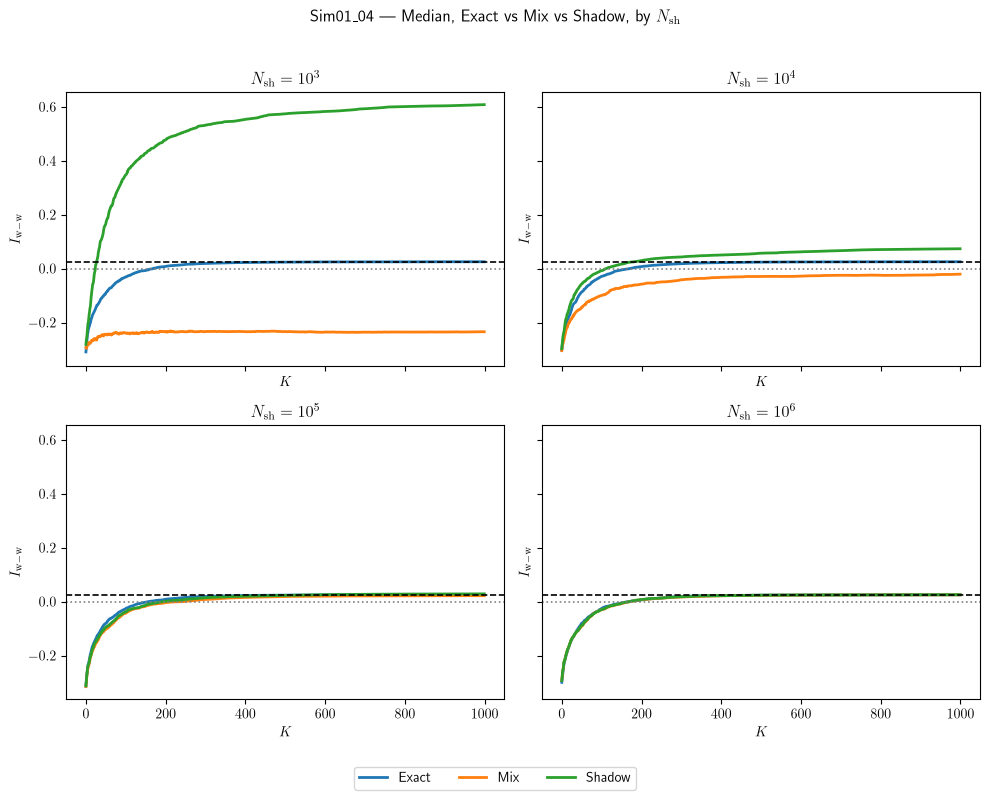

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponent in zip(axes, [3, 4, 5, 6]):
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exact")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mix")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim01\_04 --- Median, Exact vs Mix vs Shadow, by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_04_triple_median.pdf"))
plt.show()

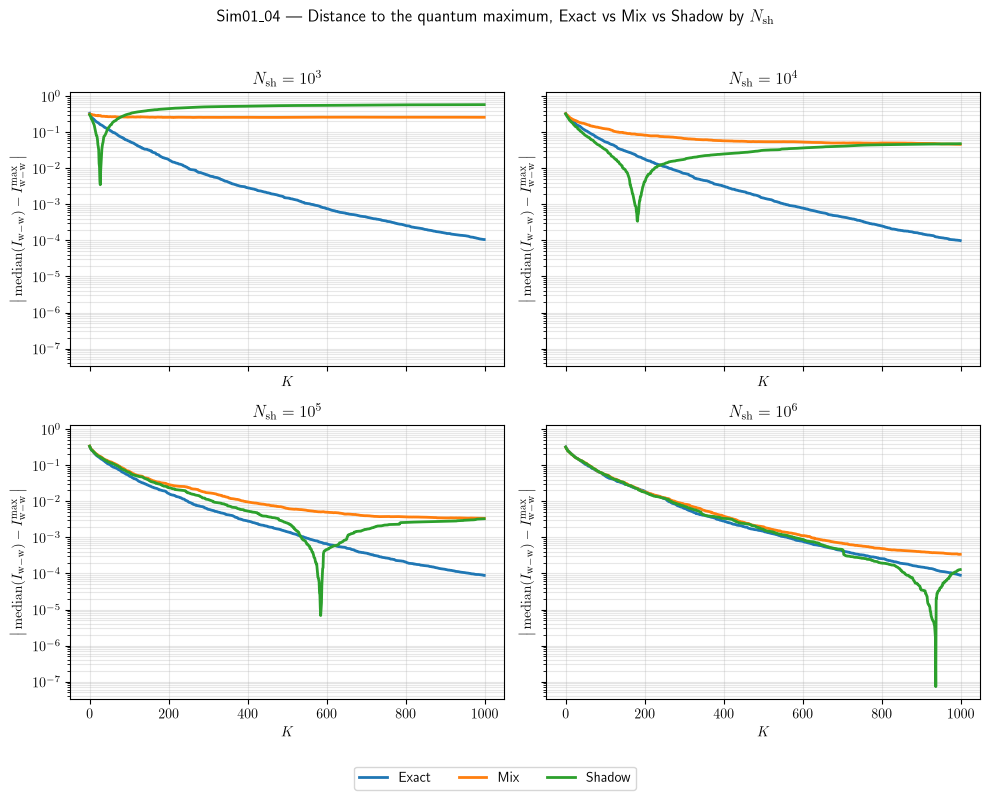

In [12]:
floor = 1e-12
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponent in zip(axes, [3, 4, 5, 6]):
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    median_ex, median_mix, median_sh = Data['median_ex'], Data['median_mix'], Data['median_sh']

    dist_ex = np.clip(np.abs(median_ex - QUANTUM_MAX), floor, None)
    dist_mix = np.clip(np.abs(median_mix - QUANTUM_MAX), floor, None)
    dist_sh = np.clip(np.abs(median_sh - QUANTUM_MAX), floor, None)
    it = np.arange(len(dist_ex))

    ax.plot(it, dist_ex, linewidth=2, label="Exact")
    ax.plot(it, dist_mix, linewidth=2, label="Mix")
    ax.plot(it, dist_sh, linewidth=2, label="Shadow")
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\left|\,\mathrm{median}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim01\_04 --- Distance to the quantum maximum, Exact vs Mix vs Shadow by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_04_distance_to_quantum_max.pdf"))
plt.show()

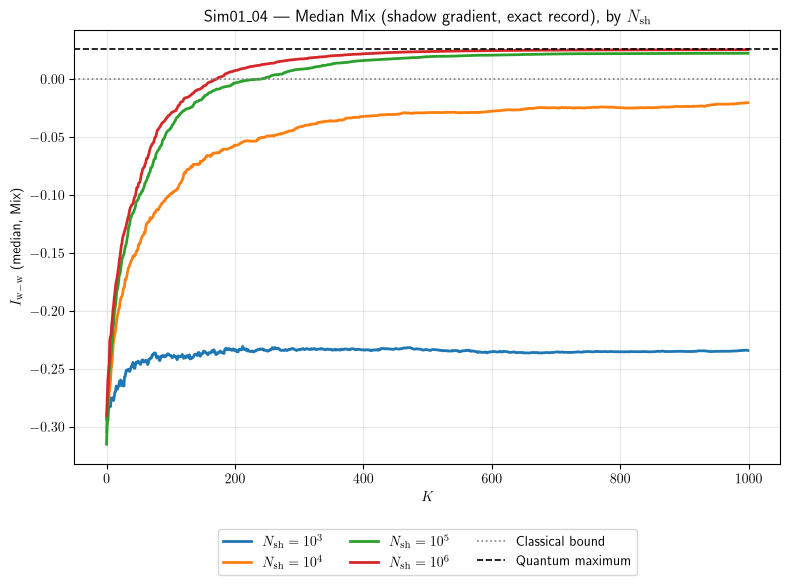

In [13]:
plt.figure(figsize=(8, 6))

for exponent in [3, 4, 5, 6]:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data['median_mix']))
    plt.plot(it, Data['median_mix'], linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponent}$")

plt.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
plt.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$ (median, Mix)")
plt.title(r"Sim01\_04 --- Median Mix (shadow gradient, exact record), by $N_{\rm sh}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_04_mix_comparison.pdf"))
plt.show()

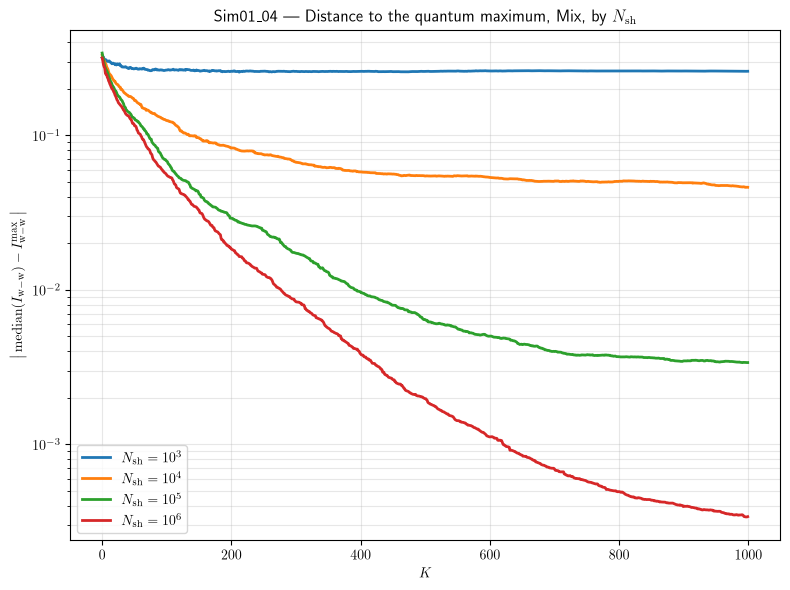

In [14]:
floor = 1e-12
plt.figure(figsize=(8, 6))

for exponent in [3, 4, 5, 6]:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    median_mix = Data['median_mix']

    dist_mix = np.clip(np.abs(median_mix - QUANTUM_MAX), floor, None)
    it = np.arange(len(dist_mix))
    plt.plot(it, dist_mix, linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponent}$")

plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{median}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_04 --- Distance to the quantum maximum, Mix, by $N_{\rm sh}$")
plt.legend(loc='lower left')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Sim01_04_mix_distance.pdf"))
plt.show()

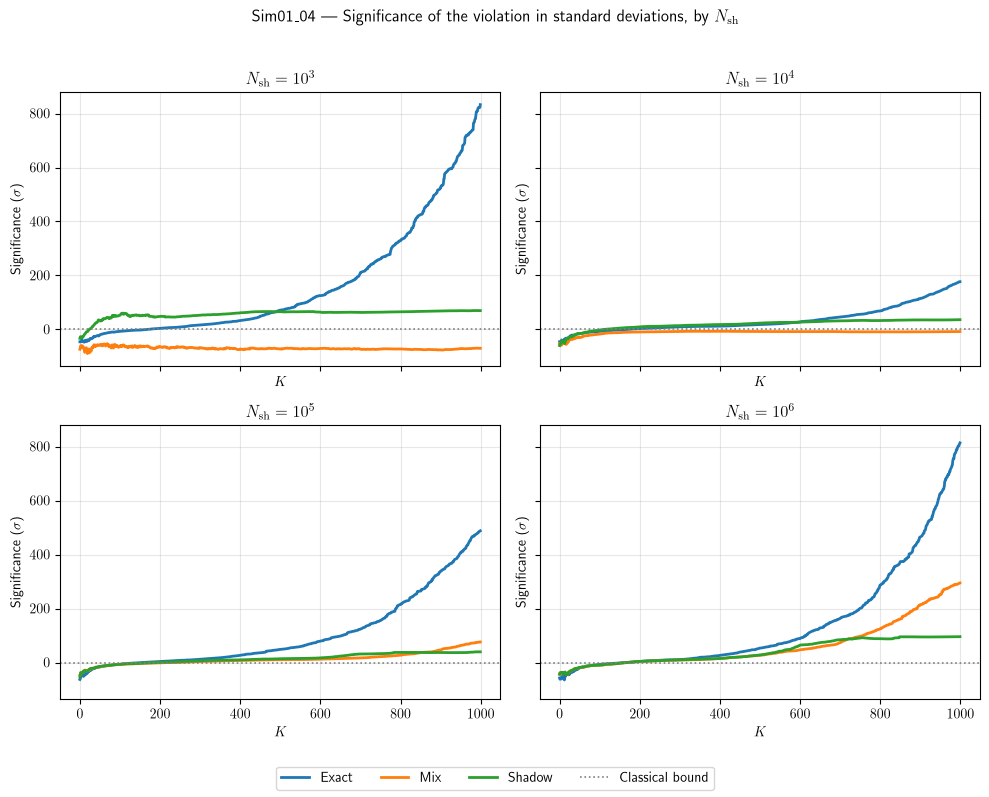

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponent in zip(axes, [3, 4, 5, 6]):
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    N_rep = int(Data['N_rep'])

    for med_key, q1_key, q3_key, label in [
        ('median_ex', 'q1_ex', 'q3_ex', "Exact"),
        ('median_mix', 'q1_mix', 'q3_mix', "Mix"),
        ('median_sh', 'q1_sh', 'q3_sh', "Shadow"),
    ]:
        median = Data[med_key]
        iqr = Data[q3_key] - Data[q1_key]
        # standard error of the median, estimated from the IQR,
        # assuming approximate normality (IQR = 1.35*sigma)
        sem = np.clip((iqr / 1.35) / np.sqrt(N_rep), 1e-12, None)
        sigma = median / sem

        it = np.arange(len(sigma))
        ax.plot(it, sigma, linewidth=2, label=label)

    ax.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponent}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"Significance ($\sigma$)")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4)
fig.suptitle(r"Sim01\_04 --- Significance of the violation in standard deviations, by $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "Sim01_04_significance.pdf"))
plt.show()

# 2. Schmidt States

The three sources of the triangular network all distribute a pure
two-qubit state in Schmidt decomposition,
$\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, with
$a\in[0,0.5]$ ($a=0.5$ recovers the maximally entangled state, $a=0$
recovers the product state $\lvert 00\rangle$).

## Simulation 02_01 — Full grid over $a$

**Data folder:** `Simulacion_02`

| Parameter | Value |
|---|---|
| State (three sources) | Schmidt decomposition, $\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, same $a$ in all three sources |
| $N_{\rm sh}$ (measurements per shadow) | $10\,000$, shadow retrained every repetition |
| `N_rep` | 100 |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |

**Description:** second scenario of the series, in which the three
sources of the triangular network distribute the same Schmidt-decomposed
state. Run over two different grids of the parameter $a$, identified as
Sim02_01 and Sim02_02, to first explore the full range and then refine
the region close to the maximally entangled state in this basis.

**Sim02_01, full grid:** $a \in \{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$,
step $0.1$, from the product state to the maximally entangled state.

**Generated files:** `Simulacion_02/Sim02_01_a{value}.npz`, one per
value of $a$, each with the raw array for each level (`Out1`, `Out2`,
`Out3`) together with `mean`, `median`, `q1` and `q3` per iteration for
each one, same as in Simulation 01.

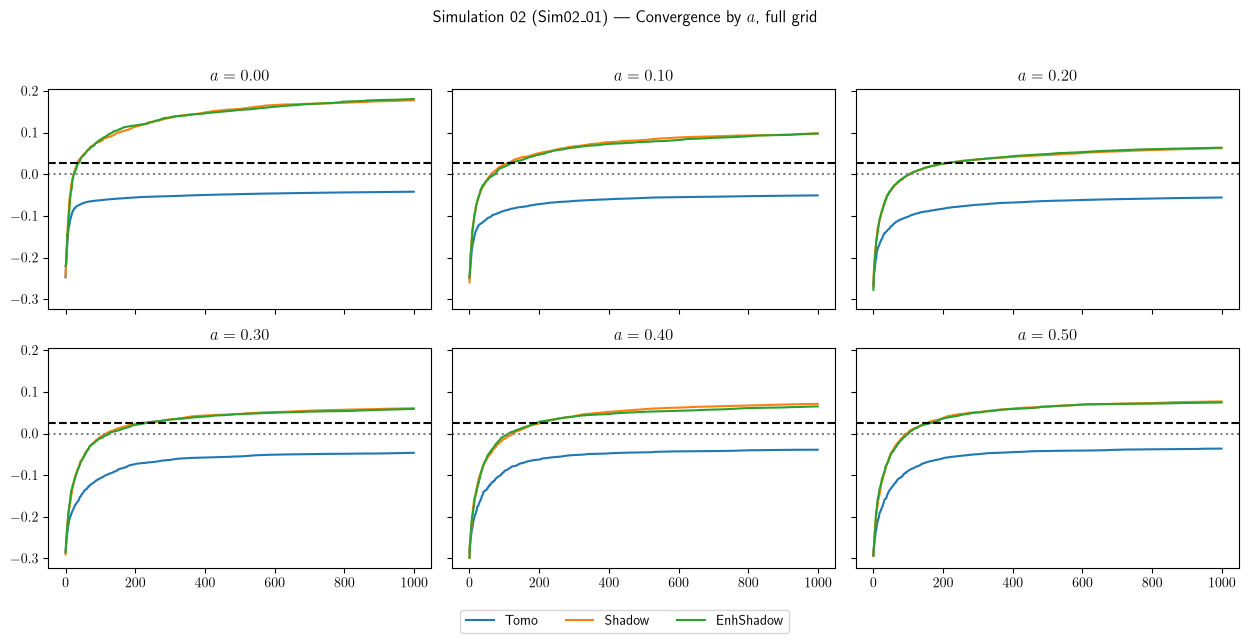

6

In [16]:
plot_convergence_grid("Sim02_01", FOLDER_SCHMIDT, "a", "a",
                      r"Simulation 02 (Sim02\_01) --- Convergence by $a$, full grid",
                      "Sim02_01_convergence_grid.pdf")

## Simulation 02_02 — Refined grid over $a$

**Data folder:** `Simulacion_02`

**Sim02_02, refined grid:** $a \in \{0.30,\ 0.35,\ 0.40,\ 0.45,\ 0.50\}$,
step $0.05$, restricted to the region $[0.3, 0.5]$ where the most
relevant behavior of $I_{\rm w-w}$ is concentrated. Same parameters as
Sim02_01 (`N_sh=10000`, `N_rep=100`, `N_it=1000`, same `gains` and
optimizer).

**Generated files:** `Simulacion_02/Sim02_02_a{value}.npz`, same
structure as Sim02_01.

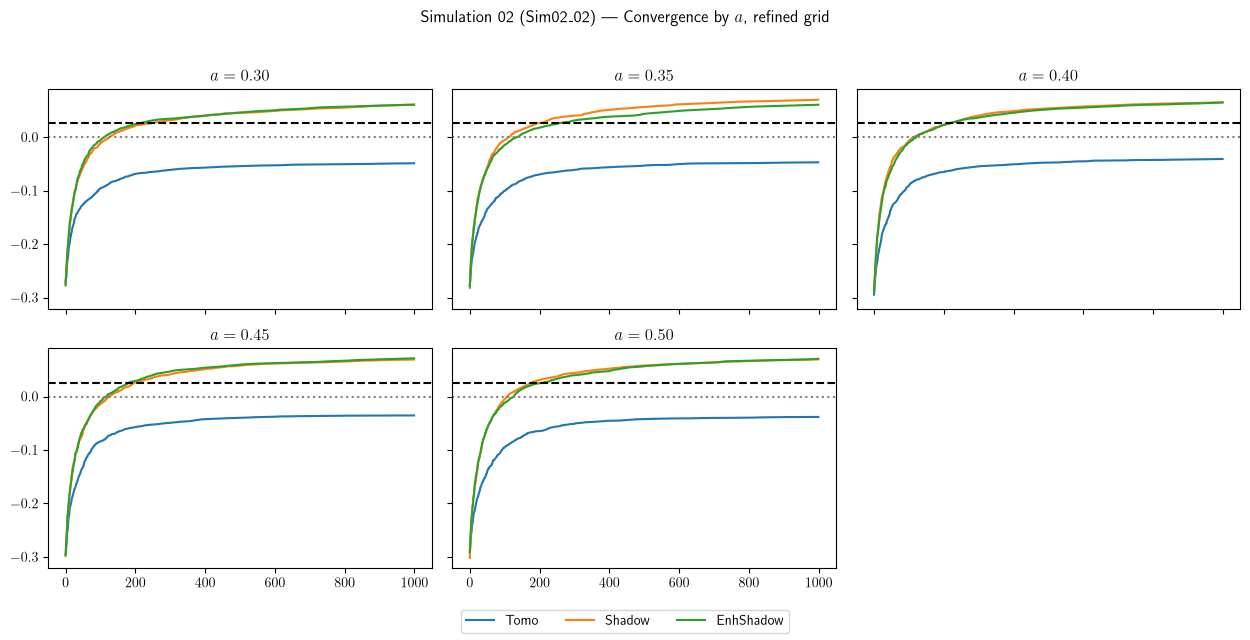

5

In [17]:
plot_convergence_grid("Sim02_02", FOLDER_SCHMIDT, "a", "a",
                      r"Simulation 02 (Sim02\_02) --- Convergence by $a$, refined grid",
                      "Sim02_02_convergence_grid.pdf")

## Simulation 02_03_01 — Exact and Shadow evaluation, Schmidt states

**Data folder:** `Simulacion_02`

| Parameter | Value |
|---|---|
| State (three sources) | Schmidt decomposition, $\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, same $a$ in all three sources |
| $N_{\rm sh}$ (measurements per shadow) | $\{10^5,\ 10^6\}$, shadow retrained every repetition |
| `N_rep` | 100 (for each of the two blocks) |
| $N_{\rm it}$ (CSPSA iterations) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |
| Evaluation blocks | Exact, and Mix+Shadow on the same trajectory |

**Description:** updates the previous version of Sim02_03, fixing the
design so that the comparison between the exact evaluation and the
shadow estimate is made on the same optimization point, not on two
independent optimizations (the same fix applied to Sim01_04). For each
value of $a$ and $N_{\rm sh}$, two blocks of `N_rep` repetitions are
run. The first, guided and evaluated entirely by `out_fun` (exact
evaluation, `Out_ex`), independent of everything else. The second, a
single optimization per repetition, guided by `obj_fun` (the shadow
decides each CSPSA step), but at each step two values of the same point
$Z$ reached are recorded simultaneously: the exact value of that point
(`Out_mix`, via `out_fun`) and the shadow-estimated value of that same
point (`Out_sh`, via `obj_fun`), without the exact evaluation
influencing the gradient or the CSPSA updates. In total,
$2\times N_{\rm rep}$ optimizations are run per combination of $a$ and
$N_{\rm sh}$, not $3\times N_{\rm rep}$.

**Sim02_03_01:** $a \in \{0.00,\ 0.25,\ 0.50\}$, each with
$N_{\rm sh}\in\{10^5,10^6\}$.

**Generated files:** `Simulacion_02/Sim02_03_01_a{value}_N1e{exp}.npz`,
each containing `Out_ex`, `Out_mix` and `Out_sh` (size `N_rep` x
$N_{\rm it}$ each), together with `mean`, `median`, `q1` and `q3` per
iteration for the three (`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, and
likewise with suffixes `_mix` and `_sh`).

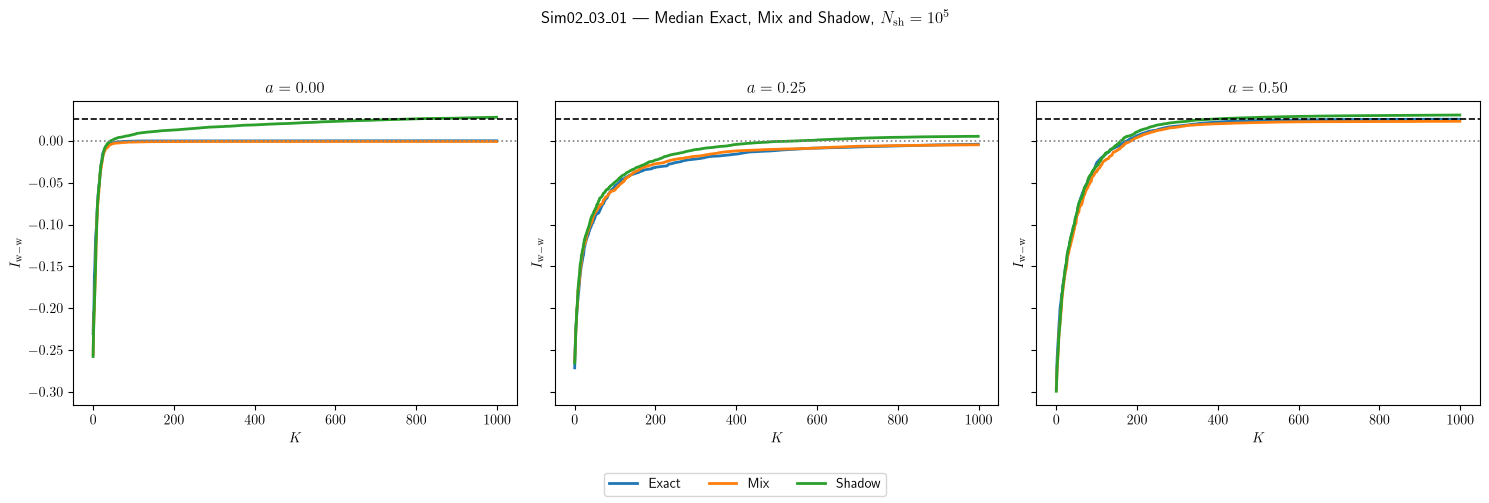

In [18]:
plot_triple_row("Sim02_03_01", FOLDER_SCHMIDT, "a", "a", [0.00, 0.25, 0.50], 5,
                 r"Sim02\_03\_01 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^5$",
                 "Sim02_03_01_N1e5.pdf", figsize=(15, 5))

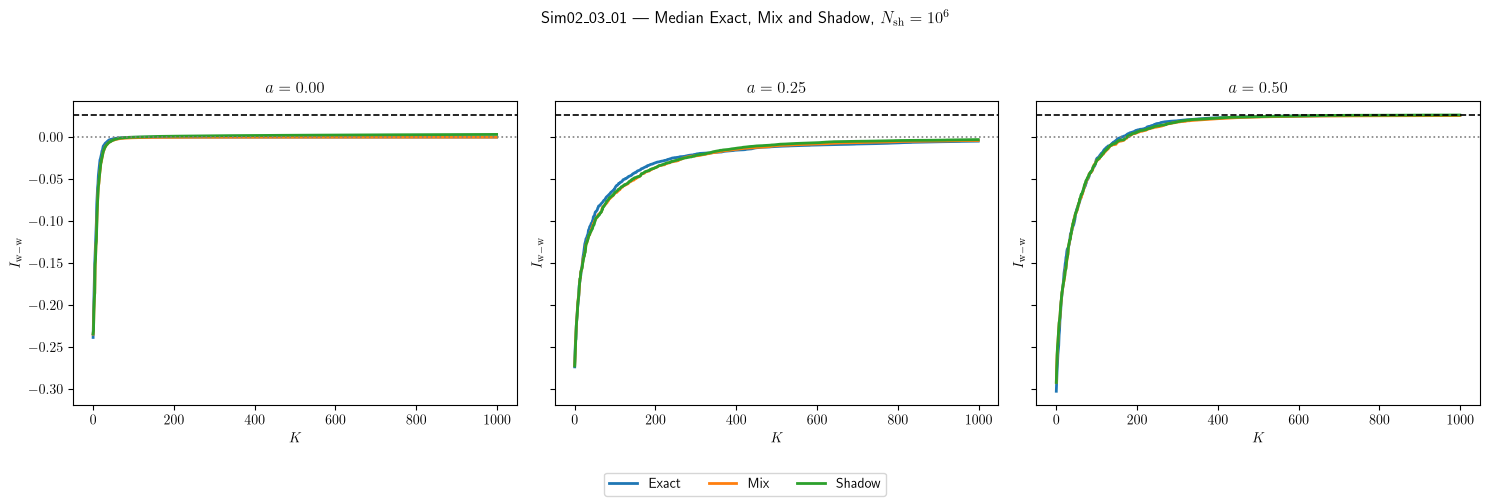

In [19]:
plot_triple_row("Sim02_03_01", FOLDER_SCHMIDT, "a", "a", [0.00, 0.25, 0.50], 6,
                 r"Sim02\_03\_01 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^6$",
                 "Sim02_03_01_N1e6.pdf", figsize=(15, 5))

## Simulation 02_03_02 — Exact and Shadow evaluation, refined grid

**Data folder:** `Simulacion_02`

**Sim02_03_02:** $a \in \{0.30,\ 0.35,\ 0.40,\ 0.45,\ 0.50\}$, each with
$N_{\rm sh}\in\{10^5,10^6\}$. Same design and parameters as Sim02_03_01.

**Generated files:** `Simulacion_02/Sim02_03_02_a{value}_N1e{exp}.npz`,
same structure as Sim02_03_01.

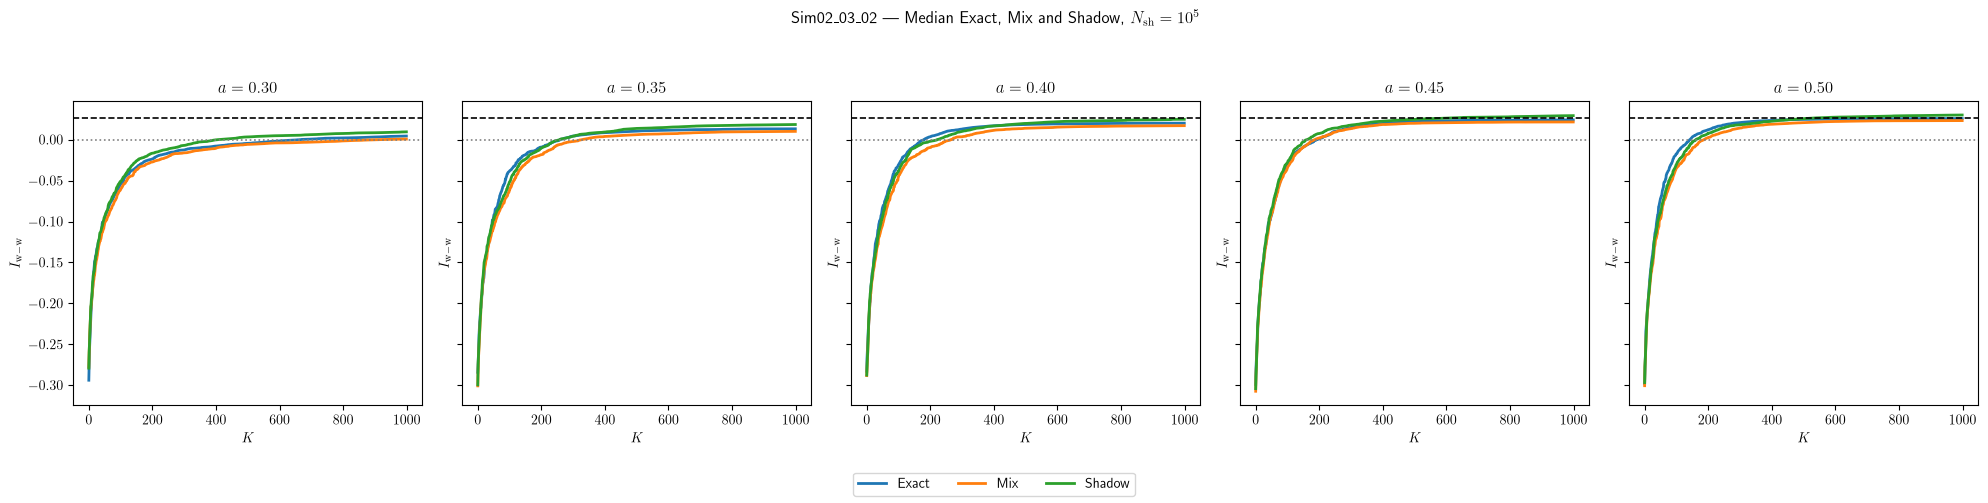

In [20]:
plot_triple_row("Sim02_03_02", FOLDER_SCHMIDT, "a", "a", [0.30, 0.35, 0.40, 0.45, 0.50], 5,
                 r"Sim02\_03\_02 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^5$",
                 "Sim02_03_02_N1e5.pdf", figsize=(20, 5))

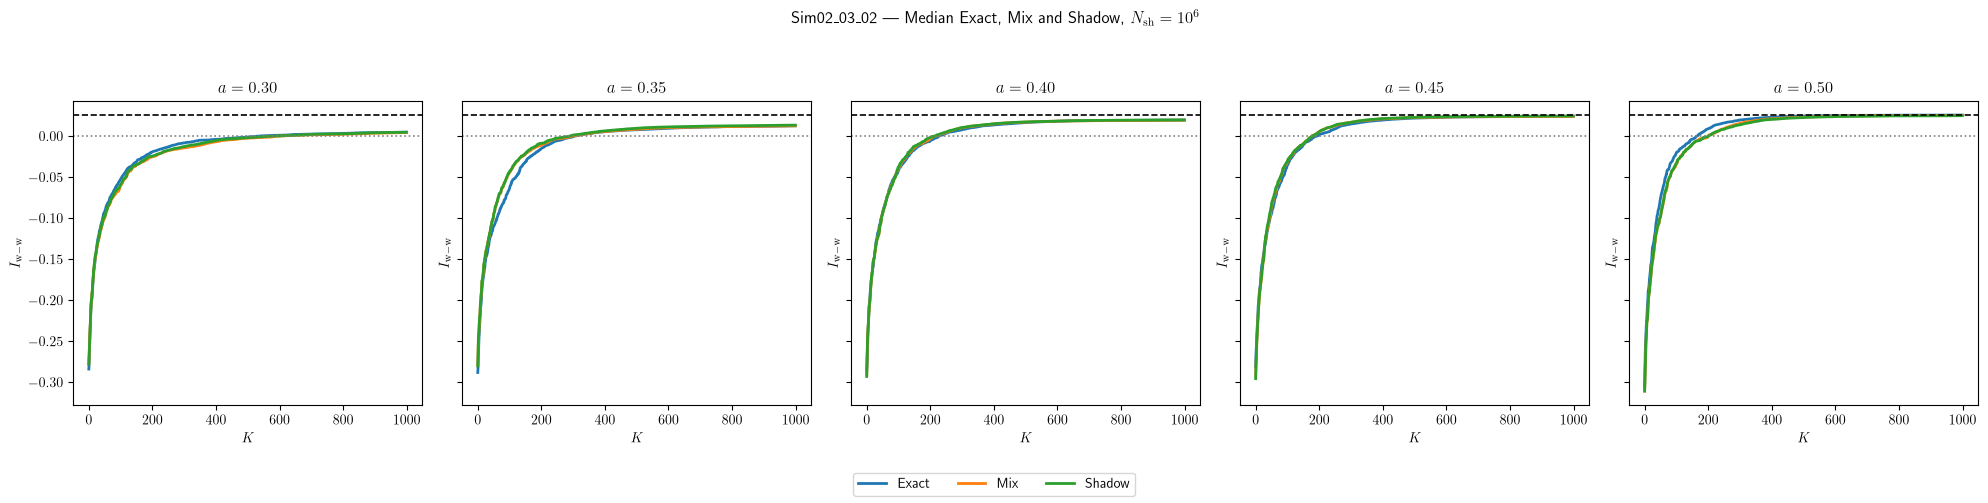

In [21]:
plot_triple_row("Sim02_03_02", FOLDER_SCHMIDT, "a", "a", [0.30, 0.35, 0.40, 0.45, 0.50], 6,
                 r"Sim02\_03\_02 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^6$",
                 "Sim02_03_02_N1e6.pdf", figsize=(20, 5))

# 3. Werner States

The three sources of the triangular network all distribute a Werner
state, $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$,
a convex mixture between the singlet and the maximally mixed state, with
purity parameter $p\in[0,1]$ ($p=1$ recovers the pure singlet, $p=0$ the
maximally mixed state).

## Simulation 03_01 — Full grid over $p$

**Data folder:** `Simulacion_03`

| Parameter | Value |
|---|---|
| State (three sources) | Werner, $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$, same $p$ in all three sources |
| $N_{\rm sh}$ (measurements per shadow) | $10\,000$, shadow retrained every repetition |
| `N_rep` | 100 |
| `N_it` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |

**Description:** third scenario of the series, in which the three
sources of the triangular network distribute the same Werner state,
varying the purity parameter $p$ between the maximally mixed state
($p=0$) and the pure singlet ($p=1$). Run over two different grids of
$p$, identified as Sim03_01 and Sim03_02, to first explore the full
range and then refine the region close to the pure state.

**Sim03_01, full grid:** $p \in \{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6,\ 0.7,\ 0.8,\ 0.9,\ 1.0\}$,
step $0.1$.

**Generated files:** `Simulacion_03/Sim03_01_p{value}.npz`, one per
value of $p$, each with the raw array for each level (`Out1`, `Out2`,
`Out3`) together with `mean`, `median`, `q1` and `q3` per iteration for
each one.

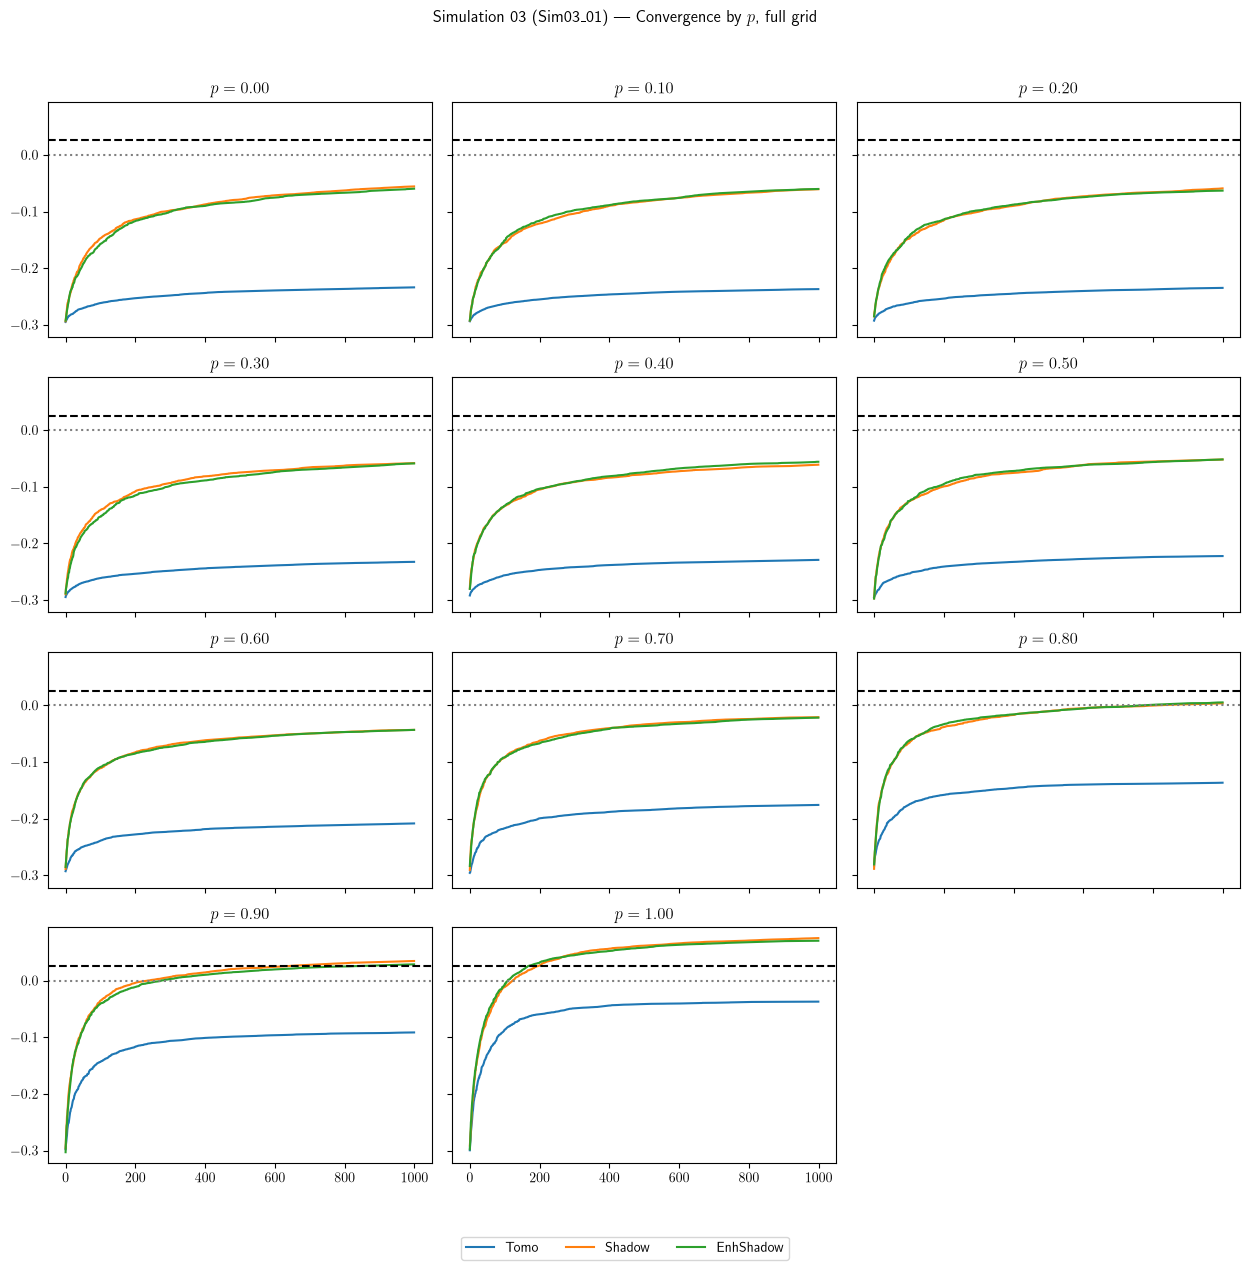

11

In [22]:
plot_convergence_grid("Sim03_01", FOLDER_WERNER, "p", "p",
                      r"Simulation 03 (Sim03\_01) --- Convergence by $p$, full grid",
                      "Sim03_01_convergence_grid.pdf")

## Simulation 03_02 — Refined grid over $p$

**Data folder:** `Simulacion_03`

**Sim03_02, refined grid:** $p \in \{0.90,\ 0.91,\ \dots,\ 1.00\}$, step
$0.01$, restricted to the region $[0.9, 1.0]$. Same parameters as
Sim03_01 (`N_sh=10000`, `N_rep=100`, `N_it=1000`, same `gains` and
optimizer).

**Generated files:** `Simulacion_03/Sim03_02_p{value}.npz`, same
structure as Sim03_01.

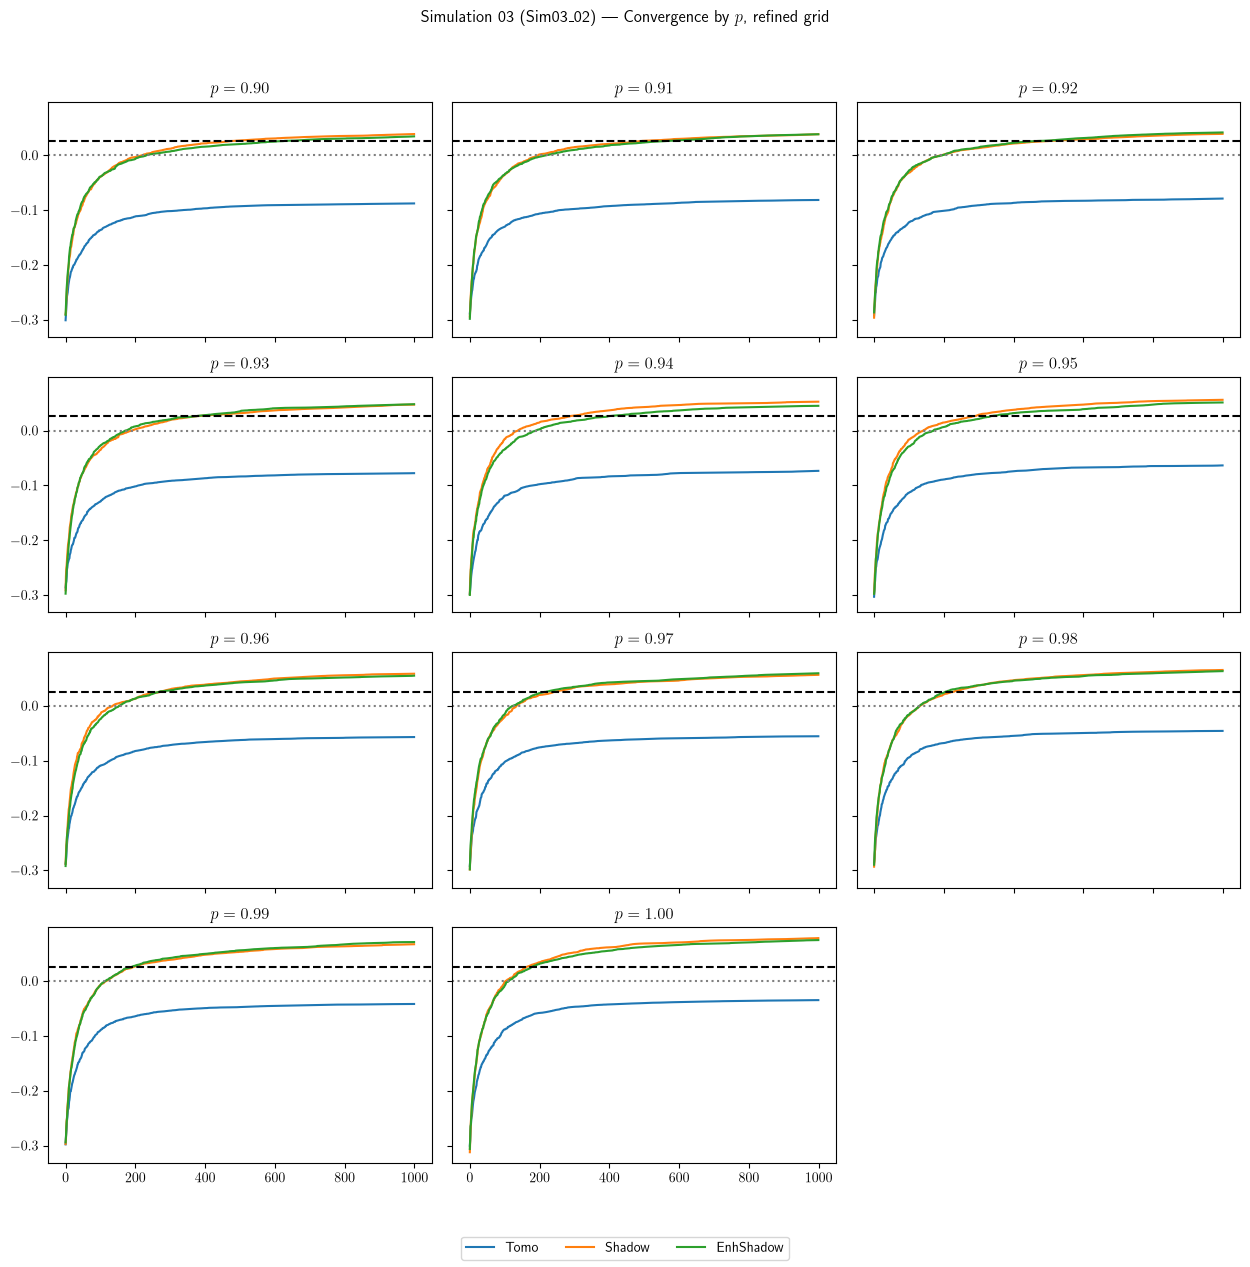

11

In [23]:
plot_convergence_grid("Sim03_02", FOLDER_WERNER, "p", "p",
                      r"Simulation 03 (Sim03\_02) --- Convergence by $p$, refined grid",
                      "Sim03_02_convergence_grid.pdf")

## Simulation 03_03_01 — Exact and Shadow evaluation, Werner states

**Data folder:** `Simulacion_03`

| Parameter | Value |
|---|---|
| State (three sources) | Werner, $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$, same $p$ in all three sources |
| $N_{\rm sh}$ (measurements per shadow) | $\{10^5,\ 10^6\}$, shadow retrained every repetition |
| `N_rep` | 100 (for each of the two blocks) |
| $N_{\rm it}$ (CSPSA iterations) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizer | CSPSA (`minimize=False`, maximization) |
| Evaluation blocks | Exact, and Mix+Shadow on the same trajectory |

**Description:** updates the previous version of Sim03_03, analogous to
the fix applied to Sim02_03, so that the comparison between the exact
evaluation and the shadow estimate is made on the same optimization
point, not on two independent optimizations. For each value of $p$ and
$N_{\rm sh}$, two blocks of `N_rep` repetitions are run. The first,
guided and evaluated entirely by `out_fun` (exact evaluation, `Out_ex`),
independent of everything else. The second, a single optimization per
repetition guided by `obj_fun` (the shadow decides each CSPSA step),
recording simultaneously at each step the exact value of the same point
$Z$ (`Out_mix`, via `out_fun`) and the shadow-estimated value of that
same point (`Out_sh`, via `obj_fun`), without the exact evaluation
influencing the gradient or the CSPSA updates. In total,
$2\times N_{\rm rep}$ optimizations are run per combination of $p$ and
$N_{\rm sh}$, not $3\times N_{\rm rep}$.

**Sim03_03_01:** $p \in \{0.0,\ 0.2,\ 0.4,\ 0.6,\ 0.8,\ 1.0\}$, each with
$N_{\rm sh}\in\{10^5,10^6\}$.

**Generated files:** `Simulacion_03/Sim03_03_01_p{value}_N1e{exp}.npz`,
each containing `Out_ex`, `Out_mix` and `Out_sh` (size `N_rep` x
$N_{\rm it}$ each), together with `mean`, `median`, `q1` and `q3` per
iteration for the three (`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, and
likewise with suffixes `_mix` and `_sh`).

**Note on the plots below:** as of this update, the source notebook still
does not include figures for Sim03_03 (unlike Sim02_03, which now has
them — see the previous section). The panels below follow the same
visual style the author just added for Sim02_03_01/02 (one row of
panels per $N_{\rm sh}$, median curves for Exact/Mix/Shadow), applied
here to the Werner sweep.

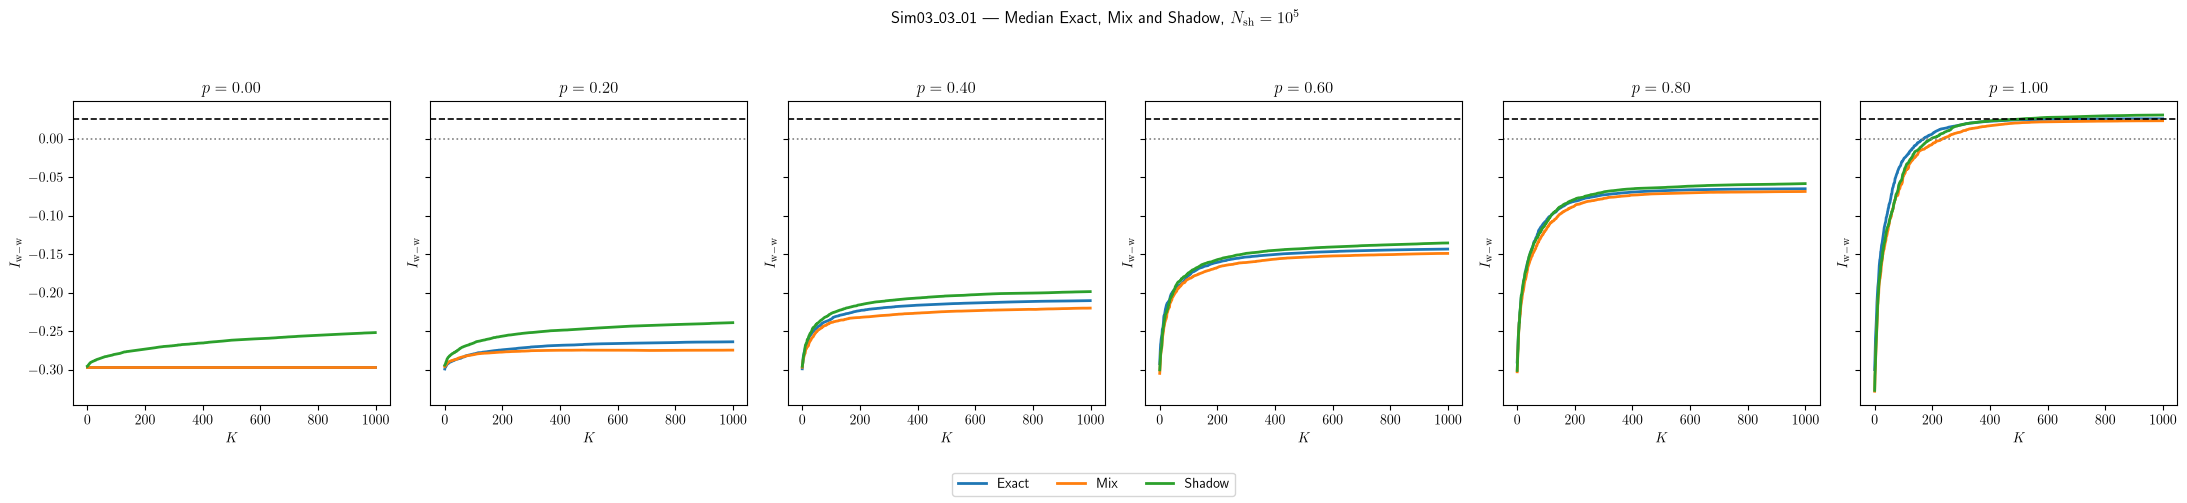

In [24]:
plot_triple_row("Sim03_03_01", FOLDER_WERNER, "p", "p",
                 [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 5,
                 r"Sim03\_03\_01 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^5$",
                 "Sim03_03_01_N1e5.pdf", figsize=(22, 5))

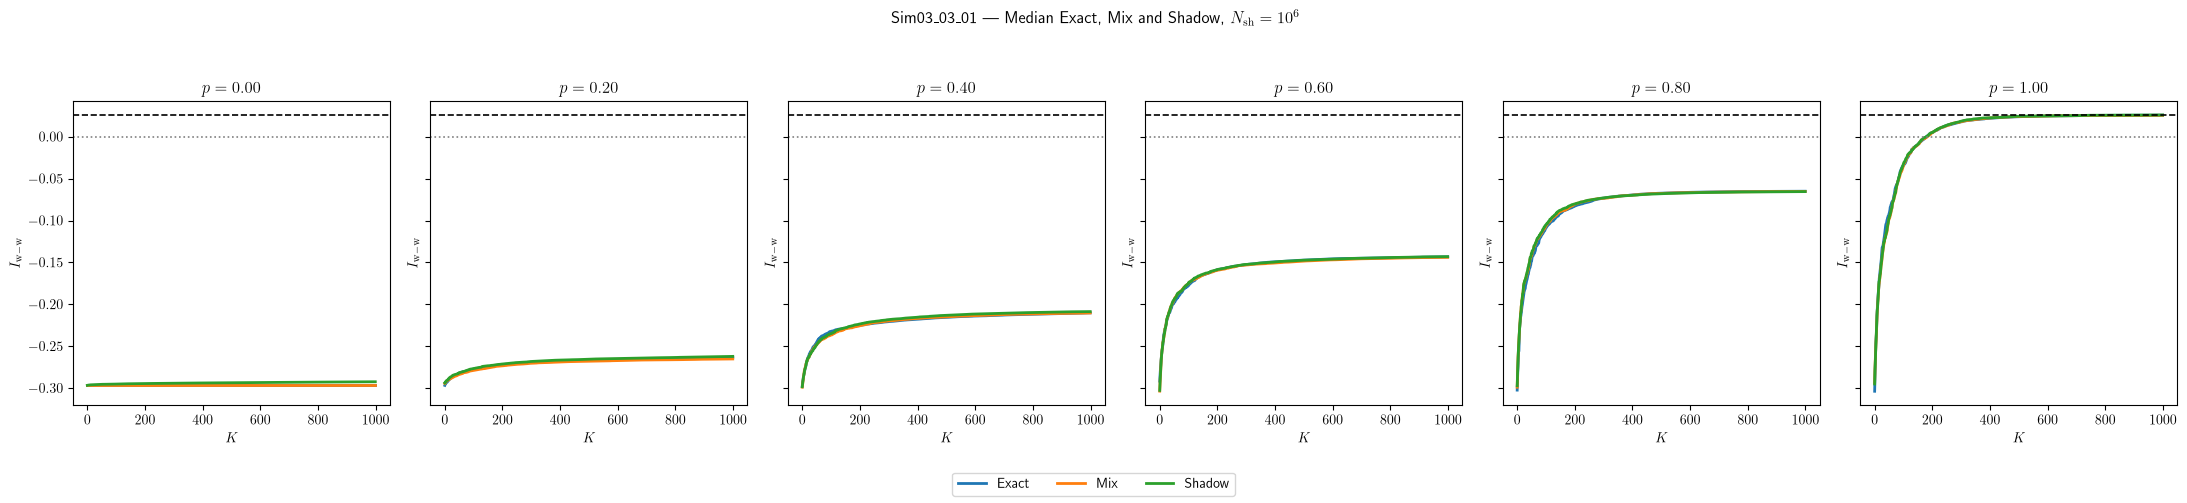

In [25]:
plot_triple_row("Sim03_03_01", FOLDER_WERNER, "p", "p",
                 [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 6,
                 r"Sim03\_03\_01 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^6$",
                 "Sim03_03_01_N1e6.pdf", figsize=(22, 5))

## Simulation 03_03_02 — Exact and Shadow evaluation, refined grid

**Data folder:** `Simulacion_03`

**Sim03_03_02:** $p \in \{0.90,\ 0.92,\ 0.94,\ 0.96,\ 0.98,\ 1.00\}$,
each with $N_{\rm sh}\in\{10^5,10^6\}$. Same design and parameters as
Sim03_03_01.

**Generated files:** `Simulacion_03/Sim03_03_02_p{value}_N1e{exp}.npz`,
same structure as Sim03_03_01.

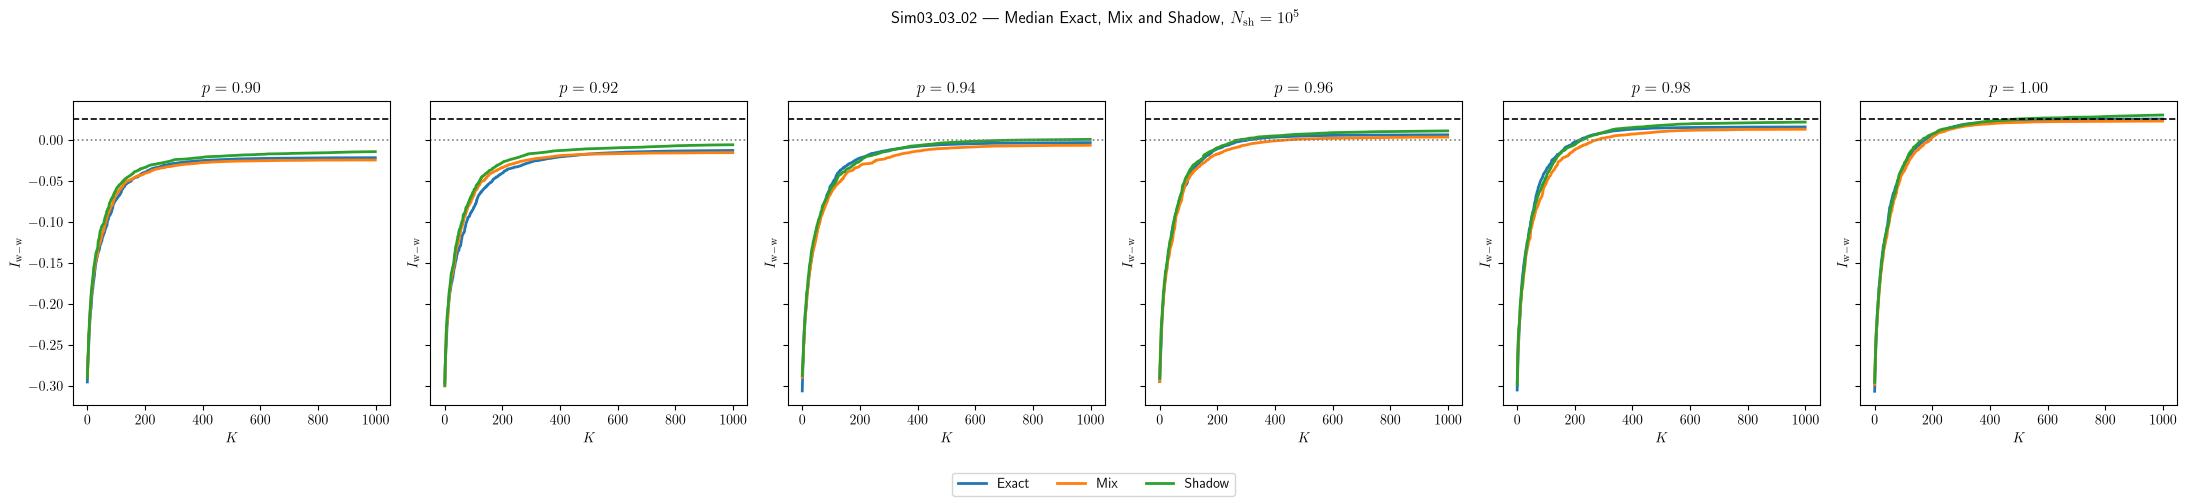

In [26]:
plot_triple_row("Sim03_03_02", FOLDER_WERNER, "p", "p",
                 [0.90, 0.92, 0.94, 0.96, 0.98, 1.00], 5,
                 r"Sim03\_03\_02 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^5$",
                 "Sim03_03_02_N1e5.pdf", figsize=(22, 5))

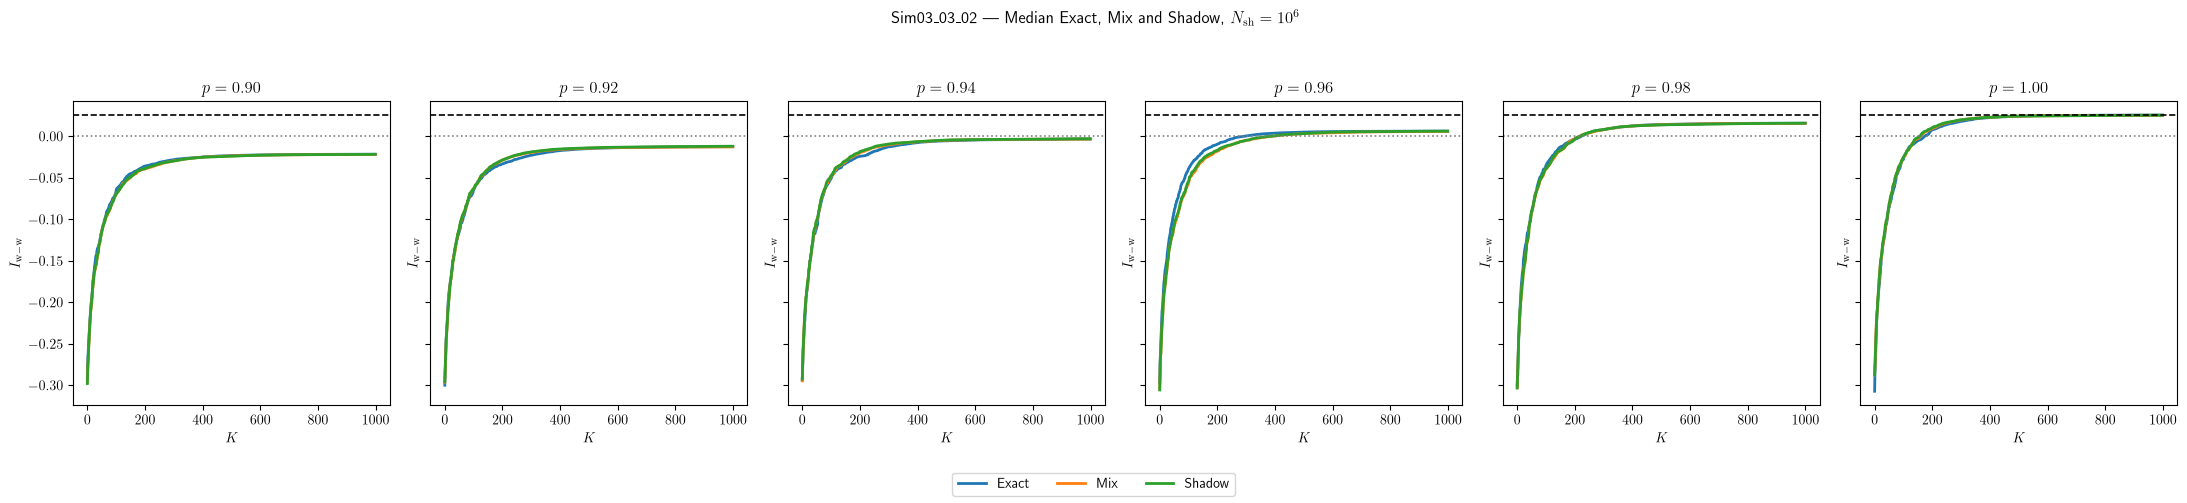

In [27]:
plot_triple_row("Sim03_03_02", FOLDER_WERNER, "p", "p",
                 [0.90, 0.92, 0.94, 0.96, 0.98, 1.00], 6,
                 r"Sim03\_03\_02 --- Median Exact, Mix and Shadow, $N_{\rm sh}=10^6$",
                 "Sim03_03_02_N1e6.pdf", figsize=(22, 5))